# Analysis of the trajectories

Now that we have our trajectory we can analyze the results. For analysis there are several modules you can use. Theoretically you can write analyses yourself using the ASE atoms object or we use modules like MDAnalysis, which is what we do now. 

Link to MDAnalysis docu: https://www.mdanalysis.org/

In [47]:
from ase.io import read, write
from ase.io.trajectory import Trajectory
import itertools
import os

As stated before, trajectories in the .traj format are practical but cannot be used in MDAnalysis. Therefore, we save it to an xyz format.

In [ ]:
try:
    frames = Trajectory("traj/04_nvt.traj")
    images = [frames[i] for i in range(len(frames))]
    write("traj/04_nvt.xyz", images)
except:
    print("Trajectory not found!")

Trajectory not found!


We want to get a radial distribution function of our MOF with our Adsorbate to see where the molecules get adsorbed. We can use the InterRDF from MDAnalysis:

https://docs.mdanalysis.org/stable/documentation_pages/analysis/rdf.html

In [49]:
import MDAnalysis as mda
from MDAnalysis.analysis.rdf import InterRDF
import numpy as np

We want to make sure that our output directories exist

In [39]:
os.makedirs("results", exist_ok=True)

Now we load our MDAnalysis universe. You can use the trajectory you created or read one that is provided in the trajectory directory.

In [40]:
try:
    u = mda.Universe("traj/04_nvt.xyz")
except:
    u = mda.Universe("../trajectories/uio66_h2o_mh-1_1.xyz", "../trajectories/uio66_h2o_mh-1_2.xyz")

### Set box dimensions

The RDF needs the box dimension to calculate densities. The xyz format does not store cell parameters but we can set them from the traj file:

In [50]:
at0 = read("traj/03_equilibration.traj", index=-1)
at0.get_cell()
a,b,c,alpha,beta,gamma = at0.cell.cellpar()
u.dimensions = np.array([a,b,c,alpha,beta,gamma], dtype=float)

### Select and group atoms

As ML potentials do not know about molecular connectivity we need to group the atoms manually. ASE does not change the order of the atoms unless you tell it to so we know that the difference between the initial structure and the whole system is the molecule we added.

In [ ]:
atoms = read("traj/03_equilibration.traj", index = "-1")
mof = read("02_uio-66.cif")

#residues = ["mof","co2"]
residues = ["mof","h2o"]
n_atoms_mof = len(mof) - 1

atoms = {}
if residues[1] == "co2":
    atoms["co2"]= ["C", "O"]
else:
    atoms["h2o"]= ["O", "H"]

atoms["mof"] =["C","H","O","Zr"]

sel = {}

for residue in residues:
    sel[residue]={}
    for atom in atoms[residue]:
        if residue == "mof":
            sel[residue][atom] = u.select_atoms(f"name {atom} and (index 0:{n_atoms_mof})")
        else:
            sel[residue][atom] = u.select_atoms(f"name {atom} and not (index 0:{n_atoms_mof})")


/scratch/data/marion/miniforge3/envs/ml/lib/python3.12/site-packages/MDAnalysis/analysis/base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


### Get the RDF ready

We want to examine all combination of elements in the MOF and our adsorbate, then we can use InterRDF between those pairs:

In [ ]:
if residues[1] == "co2":
    combs = list(itertools.product(atoms["mof"], atoms["co2"]))
else:
    combs = list(itertools.product(atoms["mof"], atoms["h2o"]))

rdf = {}

for a1,a2 in combs:
    if residues[1] == "co2":
        rdf[a1+a2] = InterRDF(sel["mof"][a1], sel["co2"][a2], range=(0.0, 8.0), nbins=400)
    else:
        rdf[a1+a2] = InterRDF(sel["mof"][a1], sel["h2o"][a2], range=(0.0, 8.0), nbins=400)
    rdf[a1+a2].run()
    data = np.column_stack([rdf[a1+a2].results.bins, rdf[a1+a2].results.rdf])
    np.savetxt(f"results/rdf_{a1}_{a2}.dat", data)

### Plot the results

Now that we calculated our functions we can visualize the results. The following exapmle is a simple multiplot in matplotlib.

In [52]:
import matplotlib.pyplot as plt

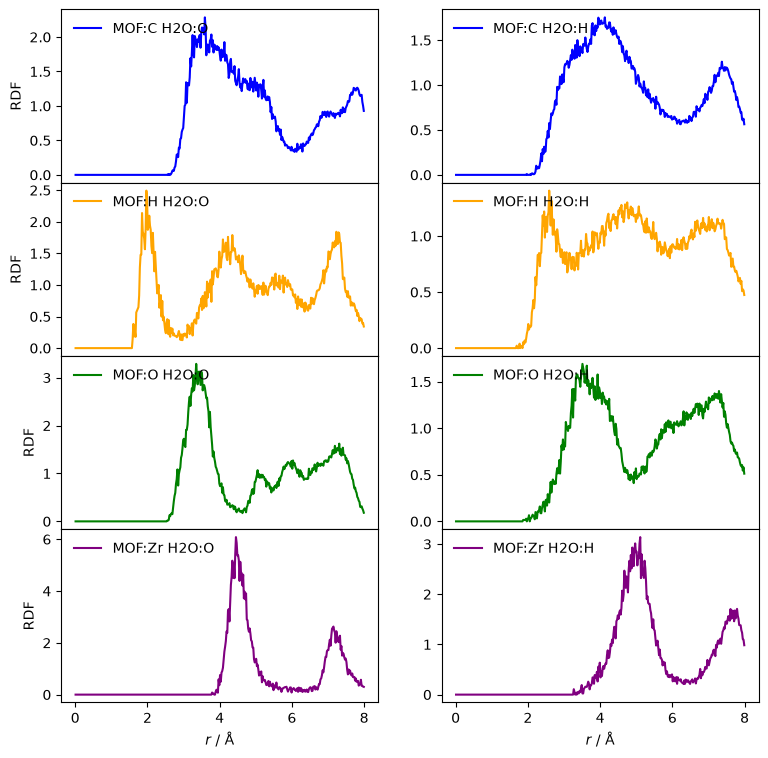

In [59]:
fig, axs = plt.subplots(len(atoms["mof"]),2)
fig.set_size_inches(9,9)

colors = ["blue","orange","green","purple"]

for n1,a1 in enumerate(atoms["mof"]):
    if residues[1] == "co2":
        for n2,a2 in enumerate(atoms["co2"]):
            axs[n1,n2].plot(rdf[a1+a2].results.bins, rdf[a1+a2].results.rdf, label=f"MOF:{a1} CO2:{a2}", color = colors[n1])
            axs[n1,n2].legend(loc = "upper left",frameon = False)  
    else:
        for n2,a2 in enumerate(atoms["h2o"]):
            axs[n1,n2].plot(rdf[a1+a2].results.bins, rdf[a1+a2].results.rdf, label=f"MOF:{a1} H2O:{a2}", color = colors[n1])
            axs[n1,n2].legend(loc = "upper left",frameon = False)

fig.subplots_adjust(hspace = 0)

for i in range(2):
    axs[3,i].set_xlabel(r"$r~/~\rm{\AA}$")

for i in range(4):
    axs[i,0].set_ylabel("RDF")


if residues[1] == "co2":
    fig.savefig("results/rdf_single_mh-1_h2o.pdf", bbox_inches="tight",dpi=300)
else:   
    fig.savefig("results/rdf_single_mh-1_co2.pdf", bbox_inches="tight",dpi=300)



#### Congratulations you have your first results!

# Comparing different Molecules/Models

If you have time left, you can calculate the RDF:

- For both molecules with the same model and compare the RDFs. What do you see? Is this behavior what you expected?
- For the same molecule with different models. Are there differences? 
- For all models and molecules

Alternatively you can get together in groups and each of you can calculate a different models/molecule combinations. Compare the results as a team and discuss what you can see.

You can create different plots (e.g. plot both molecules into one axs in the figure).

Make sure you don't overwrite your RDFs!
